# 5장 3강: 배깅 vs 부스팅 선택과 모델 해석(SHAP)

## 실습 목표

이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 부스팅을 비교하고, SHAP으로 앙상블 모델의 예측 근거를 해석합니다.

- Random Forest와 XGBoost의 구조적 차이를 비교합니다.
- 성능과 학습 시간을 확인하여 상황에 맞는 모델 선택 기준을 정리합니다.
- Feature Importance의 특징과 한계를 확인합니다.
- TreeSHAP을 이용해 모델 전체의 **전역 해석**을 수행합니다.
- 특정 주택 한 건의 예측을 **지역 해석**합니다.
- SHAP 값의 부호를 이용하여 각 특성이 예측값을 올렸는지 내렸는지 설명합니다.

> 이 실습에서는 5장 3강 교안에 나온 배깅/부스팅 비교, Feature Importance, SHAP 전역·지역 해석 내용만 사용합니다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- scikit-learn
- xgboost
- shap
- 데이터: `Ames_Housing.csv`

### 분석 목표

주택 특성을 이용하여 `SalePrice`를 예측하는 회귀 문제입니다.

### 사용할 특성

- `OverallQual`
- `GrLivArea`
- `GarageCars`
- `GarageArea`
- `TotalBsmtSF`
- `1stFlrSF`
- `2ndFlrSF`
- `FullBath`
- `TotRmsAbvGrd`
- `YearBuilt`
- `YearRemodAdd`
- `Fireplaces`

예측 대상은 `SalePrice`입니다.

## 실습 준비

1. Ames Housing 데이터를 불러옵니다.
2. 사용할 숫자형 특성과 `SalePrice`를 선택합니다.
3. Train / Test 데이터로 분리합니다.
4. Random Forest와 XGBoost를 같은 데이터에서 비교합니다.
5. SHAP은 XGBoost 모델을 대상으로 확인합니다.

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
%config InlineBackend.figure_format = 'retina'

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "FullBath",
    "TotRmsAbvGrd",
    "YearBuilt",
    "YearRemodAdd",
    "Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train 크기:", X_train.shape)
print("Test 크기:", X_test.shape)

print("\n[결측치]")
display(X.isna().sum().to_frame("missing"))

Train 크기: (1168, 12)
Test 크기: (292, 12)

[결측치]


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


---

# 필수 1. 배깅과 부스팅 비교 및 선택

## 문제 1. Random Forest와 XGBoost를 비교하세요.

### 요구사항

다음 두 모델을 사용합니다.

```python
RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
```

각 모델에 대해 다음을 확인합니다.

1. Train 데이터로 학습합니다.
2. 학습 시간을 측정합니다.
3. Test 데이터를 예측합니다.
4. Test RMSE를 계산합니다.
5. Test R²를 계산합니다.
6. 결과를 하나의 DataFrame으로 정리합니다.

### 확인 포인트

- Random Forest가 배깅 계열이라는 점을 이해했는가?
- XGBoost가 부스팅 계열이라는 점을 이해했는가?
- 성능뿐 아니라 학습 시간도 함께 확인했는가?

In [2]:
# TODO
# Random Forest와 XGBoost의 Test RMSE, Test R², 학습 시간을 비교하세요.

models = {
    'RF' : RandomForestRegressor(n_estimators=200, random_state=42),
    "XGB": XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
}

result = []

for name, model in models.items():
    start_time = time.perf_counter()
    
    model.fit(X_train, y_train)

    end_time = time.perf_counter()

    progress_time = end_time - start_time

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    result.append({
        'model' : name,
        'RMSE' : rmse,
        "R2" : r2,
        "progress_time" : progress_time
    }) 

result = pd.DataFrame(result).round(4)

result

,model,RMSE,R2,progress_time
0,RF,29206.6466,0.8888,0.6082
1,XGB,28405.3201,0.8948,0.1481


### Q1. Random Forest와 XGBoost의 학습 방식은 어떻게 다른가요?

**답변:**  
- Random Forest
    - Bagging
    - 여러 나무를 독립적으로 학습하고 예측을 평균

- XGBoost
    - Boosting
    - 나무를 순차적으로 쌓으면서 앞 모델이 남긴 오차를 다음 모델이 보완

### Q2. 다음 상황에서 어떤 방식을 우선 후보로 생각할 수 있는지 작성하세요.

1. 빠르게 베이스라인을 만들고 싶고 튜닝 여력이 적음
    - Random Forest
    

2. 시간을 들여 예측 성능을 더 끌어올리고 싶음
    - Boosting 계열

3. 노이즈가 많아 과적합 위험을 조심해야 함
    - Random Forest

---

# 필수 2. Feature Importance와 SHAP 전역 해석

## 문제 1. XGBoost의 Feature Importance를 확인하세요.

### 요구사항

1. 필수 1에서 학습한 XGBoost 모델을 사용합니다.
2. `feature_importances_`를 이용합니다.
3. 특성명과 중요도를 DataFrame으로 만듭니다.
4. 중요도가 높은 순서대로 정렬합니다.
5. 막대그래프로 표시합니다.

### 확인 포인트

- 어떤 특성이 모델 전체에서 중요하게 사용되었는지 확인했는가?
- 중요도의 크기는 알 수 있지만 방향은 알 수 없다는 점을 이해했는가?

,feature,importance
0,OverallQual,0.466007
2,GarageCars,0.131052
1,GrLivArea,0.086469
5,1stFlrSF,0.061165
7,FullBath,0.046529
6,2ndFlrSF,0.042468
4,TotalBsmtSF,0.041869
11,Fireplaces,0.040955
10,YearRemodAdd,0.034265
9,YearBuilt,0.027039


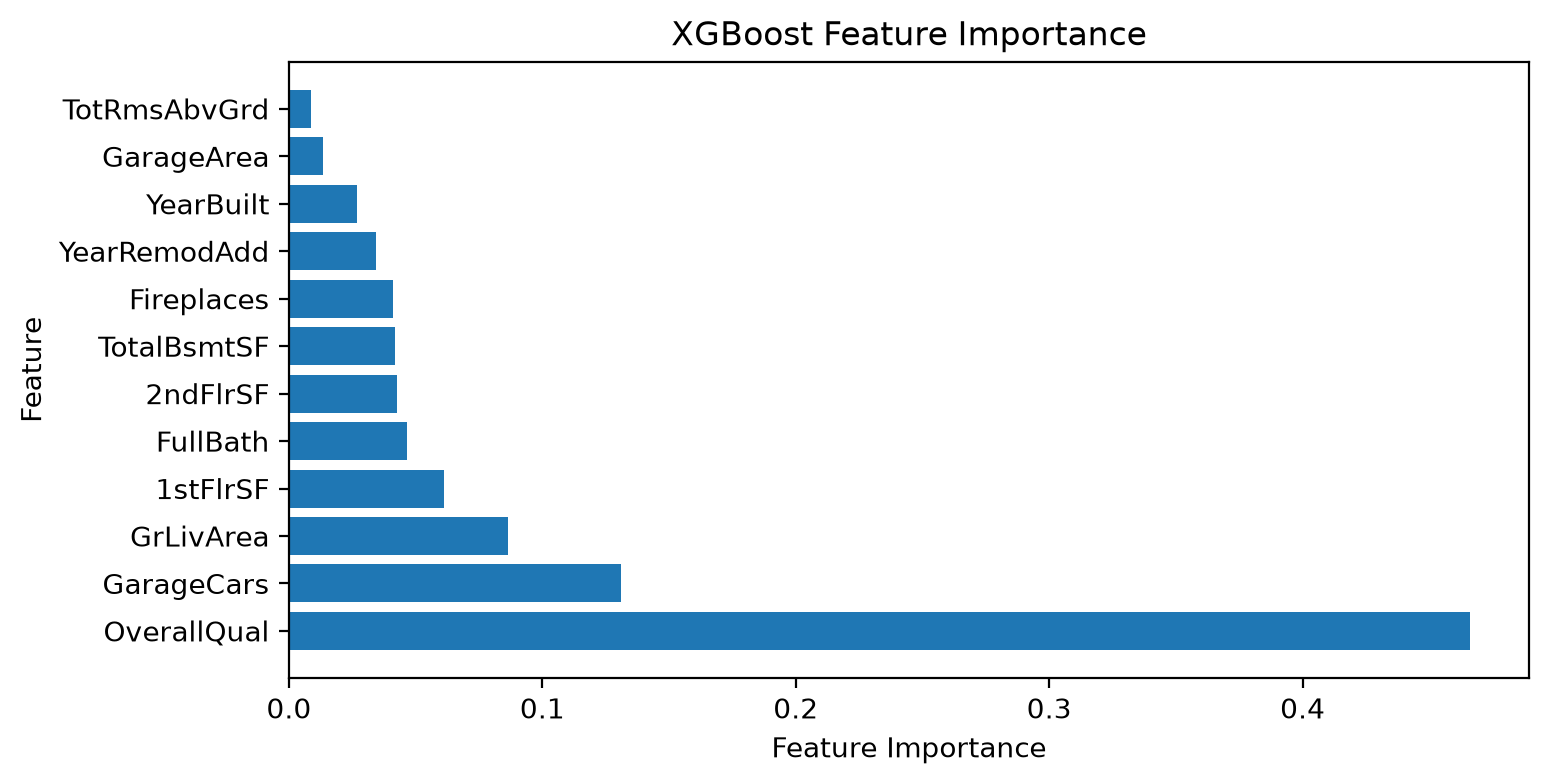

In [3]:
# TODO
# XGBoost의 Feature Importance를 표와 그래프로 확인하세요.

xgb_model = models["XGB"]

# feature importance DataFrame 생성
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
})

# 중요도가 높은 순서대로 정렬
importance_df = importance_df.sort_values(by="importance", ascending=False)

display(importance_df)

# 막대그래프
plt.figure(figsize=(8, 4))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.show()

> **해석 :**   
> Overall이 약 0.46으로 현재 모델에서 중요도를 차지하고 있다.   
> GarageCars가 약 0.13으로 현재 모델에서 두번쨰로 높은 중요도를 차지하고 있다.


### Q3. Feature Importance만으로는 알기 어려운 정보는 무엇인가요?

**답변:**  
- 예측을 높이는지, 낮추는지에 대한 방향성(음/양)
- 특정 샘플 한 건에 대한 개별적인 기여도(중요도)의 근거

## 문제 2. TreeSHAP으로 전역 중요도를 확인하세요.

### 요구사항

1. `shap.TreeExplainer()`에 XGBoost 모델을 전달합니다.
2. Test 데이터의 SHAP 값을 계산합니다.
3. `shap.plots.bar()`로 전역 중요도를 확인합니다.
4. SHAP 절댓값의 평균도 계산하여 특성별 중요도를 DataFrame으로 정리합니다.
5. 상위 특성을 확인합니다.

### 확인 포인트

- SHAP은 각 특성이 예측값에 기여한 정도를 계산한다는 점을 이해했는가?
- 전역 SHAP에서는 여러 샘플의 기여도 크기를 종합해 전체 중요도를 볼 수 있는가?

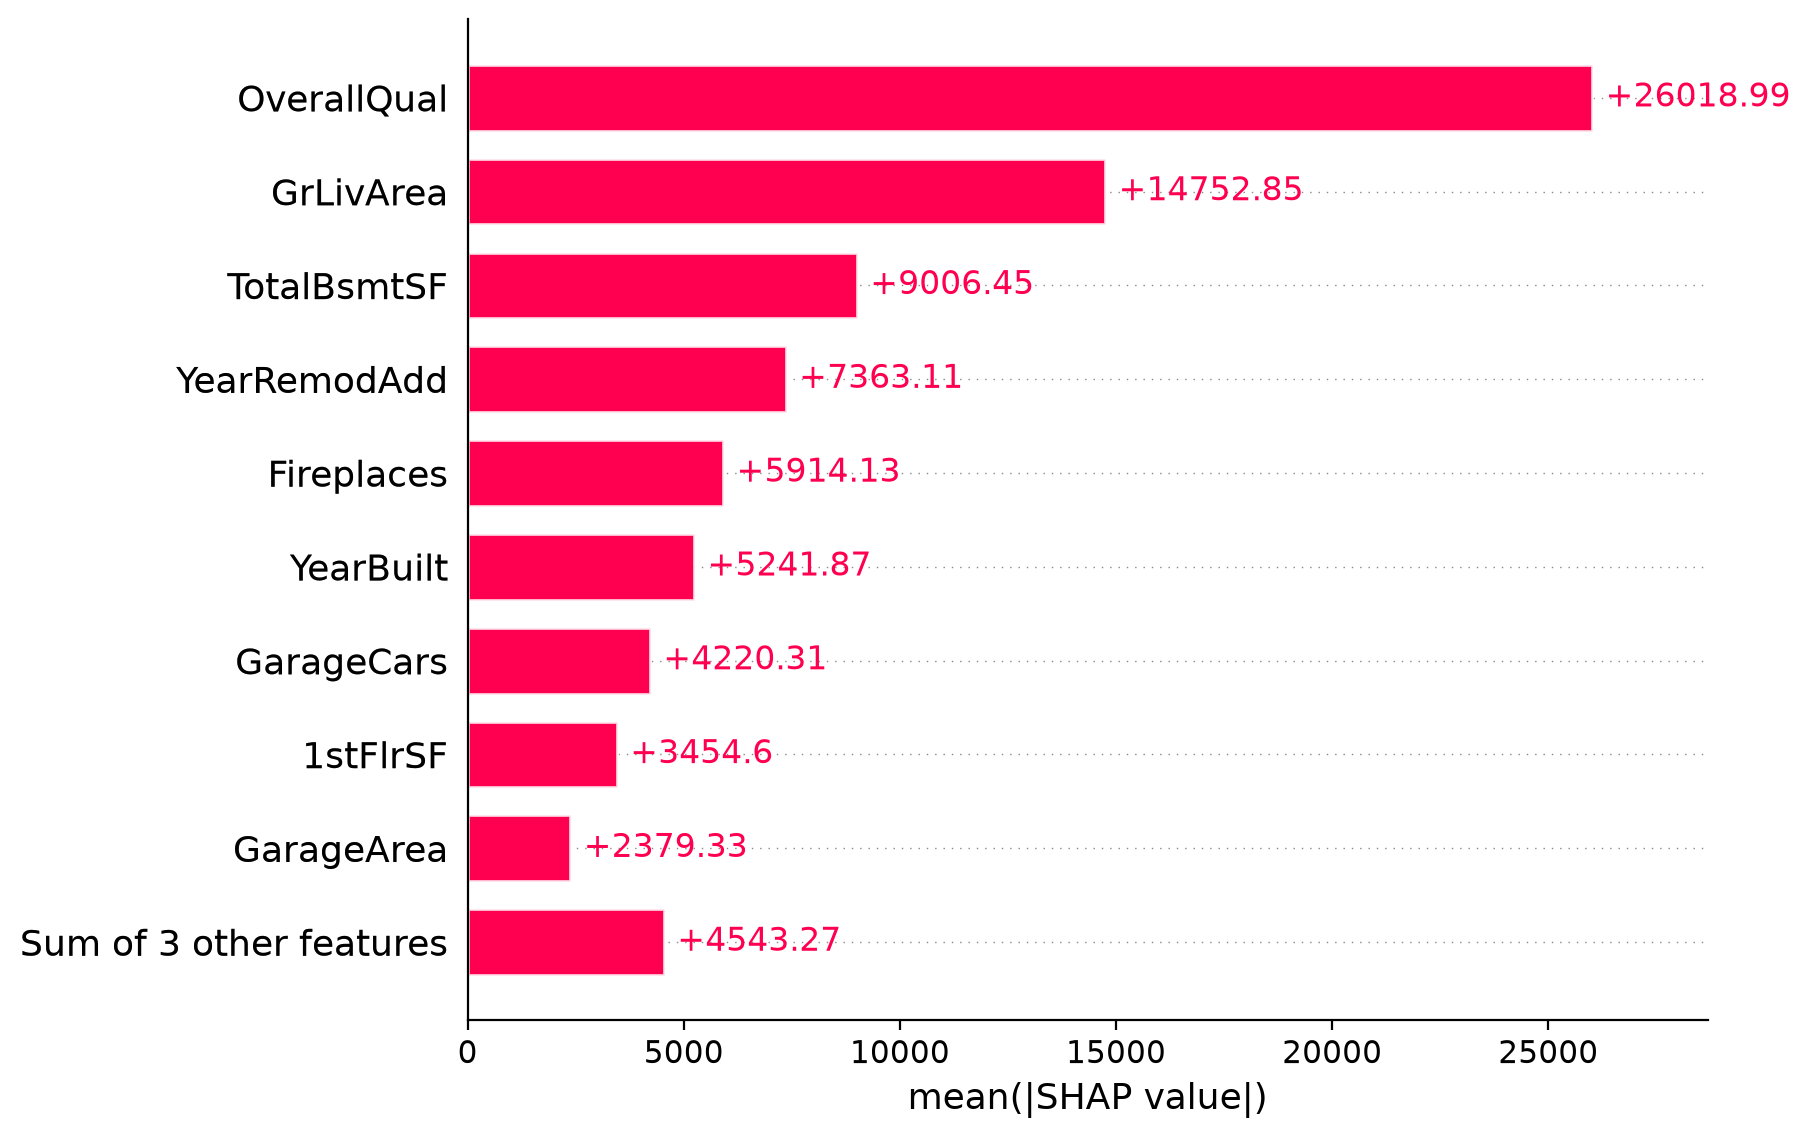

,feature,mean_abs_shap
0,OverallQual,26018.992188
1,GrLivArea,14752.850586
2,TotalBsmtSF,9006.453125
3,YearRemodAdd,7363.110352
4,Fireplaces,5914.131348
5,YearBuilt,5241.869141
6,GarageCars,4220.305664
7,1stFlrSF,3454.599609
8,GarageArea,2379.325684
9,2ndFlrSF,2307.338867


In [4]:
# TODO
# TreeSHAP을 이용해 XGBoost 모델의 전역 SHAP 중요도를 확인하세요.


xgb_model = models["XGB"]

# 1. TreeExplainer 생성
explainer = shap.TreeExplainer(xgb_model)

# 2. Test 데이터의 SHAP 값 계산
shap_values = explainer(X_test)

# 3. 전역 중요도 시각화
shap.plots.bar(shap_values)

# 4. SHAP 절댓값의 평균 계산
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "mean_abs_shap": mean_abs_shap
})

# 중요도가 높은 순으로 정렬
shap_importance_df = shap_importance_df.sort_values(
    by="mean_abs_shap",
    ascending=False
).reset_index(drop=True)

# 5. 상위 특성 확인
shap_importance_df.head(10)

- OverallQual의 의미
    - Test 주택 각각에서 품질에 배분된 SHAP 값의 절대값을 평균했더니 26,019가격 단위였다라는 뜻

- 그래프의 막대가 빨간색이고 +표시는 상승인가요?
    - |SHAP value| 절대값이기 떄문에 항상 예측이 양인 것을 의미하는 것은 아니다.

- 기존 중요도와 순위가 다른 이유
    - 기존 모델에서 Feature Importance에서는 GarageCars가 2위였는데, SHAP에서는 7위이다.
    - SHAP에서는 Test 주택 예측 차이에 배분한 기여 크기를 평균하기 때문에
    - 앞서 Feature Importance와 계산 원리와 집계 대상이 다르기 때문에 기존 중요도와 순서가 다를 수 있다.

---

### Q4. Feature Importance와 SHAP의 가장 큰 차이는 무엇인가요?

**답변:**  
- Feature Importance는 주로 모델 전체에서 중요도의 크기를 보여준다면
- SHAP는 전역 중요도, 개별 예측을 설명할 때, 각 특성의 양수/음수의 방향성을 보고 싶을 떄까지 확인이 가능하다.

---
# 과제 1. 모델 비교·SHAP 해석과 특성 선택 전후 검증

## 배경
주택 가격 예측 모델을 성능과 학습 시간으로 비교하고, SHAP으로 예측 근거를 설명합니다. 이어서 중요한 특성을 선택했을 때 검증 성능이 어떻게 달라지는지 확인합니다.

> 필수 1·2는 연습용입니다. 아래 과제의 비교표·해석·코드를 제출하세요. 준비 단계의 `X_train`, `y_train`을 사용하되 과제용 모델을 새로 학습합니다. Test 결과로 모델이나 특성을 선택하지 않도록, Train 안에서 Validation을 분리합니다. 개별 주택 해석 대상도 Validation의 첫 번째 주택으로 맞춥니다.

## 요구사항

### 1. 같은 조건에서 모델 비교
1. `X_train`, `y_train`을 Train_sub / Validation으로 나누세요(`test_size=0.2`, `random_state=42`). 결측값이 있으면 Train_sub에서 구한 중앙값으로 두 데이터를 채우세요.
2. Random Forest(`n_estimators=200`)와 XGBoost(`n_estimators=200`, `learning_rate=0.05`, `max_depth=3`)를 같은 Train_sub에서 학습하세요. 두 모델 모두 `random_state=42`, `n_jobs=1`로 설정하세요.
3. 각 모델의 **fit에 걸린 시간**, Train_sub RMSE, Validation RMSE와 R²를 `model_comparison`으로 정리하세요. 시간은 같은 환경에서 측정하며, 한 번의 측정만으로 일반적인 속도 우열을 단정하지 마세요.
4. 예측 오차, 학습 시간, Train/Validation 오차 차이와 운영 목적을 근거로 우선 후보를 선택하세요. 모델 선택 결과와 관계없이 다음 해석은 XGBoost로 수행합니다.

### 2. Feature Importance와 SHAP 전역·지역 해석
5. 과제용 XGBoost의 `feature_importances_`와 **Train_sub의 평균 절댓값 SHAP**을 각각 순위로 정리하여 `importance_comparison`으로 비교하세요. 전역 SHAP 막대그래프도 제출하세요.
6. Validation의 첫 번째 주택의 실제 가격·예측가격을 확인하고 SHAP waterfall plot을 그리세요.
7. 해당 주택의 절댓값 SHAP 상위 5개 특성·특성값·SHAP 값을 `local_top5`로 정리하세요. 양수·음수의 의미를 설명하고 기준값 + 모든 SHAP 값의 합이 예측값과 거의 같은지 확인하세요.
8. 두 전역 중요도 산출 원리와 한계를 비교하고, 전역 순위와 개별 주택의 기여도가 다른 이유를 설명하세요.

### 3. 중요도에 근거한 특성 선택 및 검증
9. Train_sub의 평균 절댓값 SHAP이 높은 **상위 6개 특성**을 선택하세요. 특성 선택은 이번 과제의 특성 개선 시도입니다. 개수는 비교 결과를 보기 전에 6개로 고정합니다.
10. 선택한 특성만 사용하여 동일한 XGBoost 설정으로 다시 학습하세요. 기존 모델과 동일한 Train_sub / Validation 행을 사용하고, 특성 이외의 조건은 유지하세요.
11. 전체 특성 모델과 선택 특성 모델의 특성 수·학습 시간·Train RMSE·Validation RMSE·Validation R²를 `feature_comparison`으로 비교하세요. `기존 Validation RMSE - 선택 후 Validation RMSE`와 기존 대비 개선율(%)을 계산하세요.
12. 개선 여부와 채택 여부를 수치로 설명하세요. 성능이 나빠져도 원인 가능성과 한계를 타당하게 설명하면 됩니다. 검증 결과를 반복 확인하며 특성을 바꾸지 말고, 최종 일반화 성능 확인에는 별도 Test 평가가 필요함을 밝히세요.

## 해석 질문

### Q5. 전역 SHAP에서 가장 중요한 특성이 특정 주택에서도 반드시 가장 큰 영향을 주나요?
### Q6. SHAP 값이 양수/음수라는 것은 각각 무엇을 의미하나요?
### Q7. 두 모델 중 무엇을 우선 후보로 선택했나요? 성능·학습 시간·과적합 징후와 주택 가격 예측 업무를 연결하여 설명하세요.
### Q8. Feature Importance와 평균 절댓값 SHAP의 계산 원리와 한계는 무엇이며, 실제 상위 특성 순위는 어떻게 다른가요?
### Q9. 상위 6개 특성은 무엇이며, 선택 전후 RMSE 차이와 개선율은 얼마인가요? 이 시도를 채택할지와 판단의 한계를 설명하세요.

## 제출물 / 확인 포인트
- `model_comparison`, `importance_comparison`, 전역 SHAP 그래프
- 개별 주택의 실제값·예측값·waterfall plot·`local_top5`·SHAP 합 검증
- 선택한 6개 특성, `feature_comparison`, RMSE 차이와 개선율
- 계산 코드와 Q5~Q9 답변
- 동일한 검증 조건 유지, SHAP의 방향·전역/지역 구분, 관측한 개선 여부와 해석의 한계

In [5]:
# TODO 1: 같은 Train_sub / Validation으로 두 모델의 성능과 fit 시간을 비교하세요.

from sklearn.metrics import root_mean_squared_error


# 1. Train_sub / Validation 분할
X_sub, X_val, y_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)


# 결측값 처리
# Train_sub의 중앙값만 사용하여 결측값 처리
X_sub = X_sub.fillna(X_sub.median())
X_val = X_val.fillna(X_sub.median())


# 2. 모델 학습

model_comparison = []

models = {
    'RF' : RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1),
    'XGB' : XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=3)
}

for name, model in models.items():

    start_time = time.perf_counter()

    model = model.fit(X_sub, y_sub)

    end_time = time.perf_counter()
    progress_time = end_time - start_time

    # 평가
    train_pred = model.predict(X_sub)
    val_pred = model.predict(X_val)

    train_rmse = root_mean_squared_error(y_sub, train_pred)
    val_rmse = root_mean_squared_error(y_val, val_pred)
    val_r2 = r2_score(y_val, val_pred)

    model_comparison.append({
        'model' : name,
        'Train RMSE' : train_rmse,
        'Validation RMSE' : val_rmse,
        'Validation R²' : val_r2,
        'Error' : train_rmse - val_rmse,
        'progress_time' : progress_time
    })

model_comparison = pd.DataFrame(model_comparison).round(4)
model_comparison

,model,Train RMSE,Validation RMSE,Validation R²,Error,progress_time
0,RF,12367.6583,29317.7622,0.8670,-16950.1039,0.4731
1,XGB,19116.6406,27436.8457,0.8835,-8320.2051,0.1362


,Feature,XGBoost Importance,Mean Abs SHAP,XGB Rank,SHAP Rank
0,OverallQual,0.466007,24893.847656,1,1
1,GrLivArea,0.086469,14084.577148,3,2
2,TotalBsmtSF,0.041869,8908.132812,7,3
3,YearRemodAdd,0.034265,7571.487305,9,4
4,Fireplaces,0.040955,5818.240234,8,5
5,YearBuilt,0.027039,5751.895508,10,6
6,GarageCars,0.131052,3919.210693,2,7
7,1stFlrSF,0.061165,3391.897217,4,8
8,GarageArea,0.013282,2349.659424,11,9
9,2ndFlrSF,0.042468,2155.299805,6,10


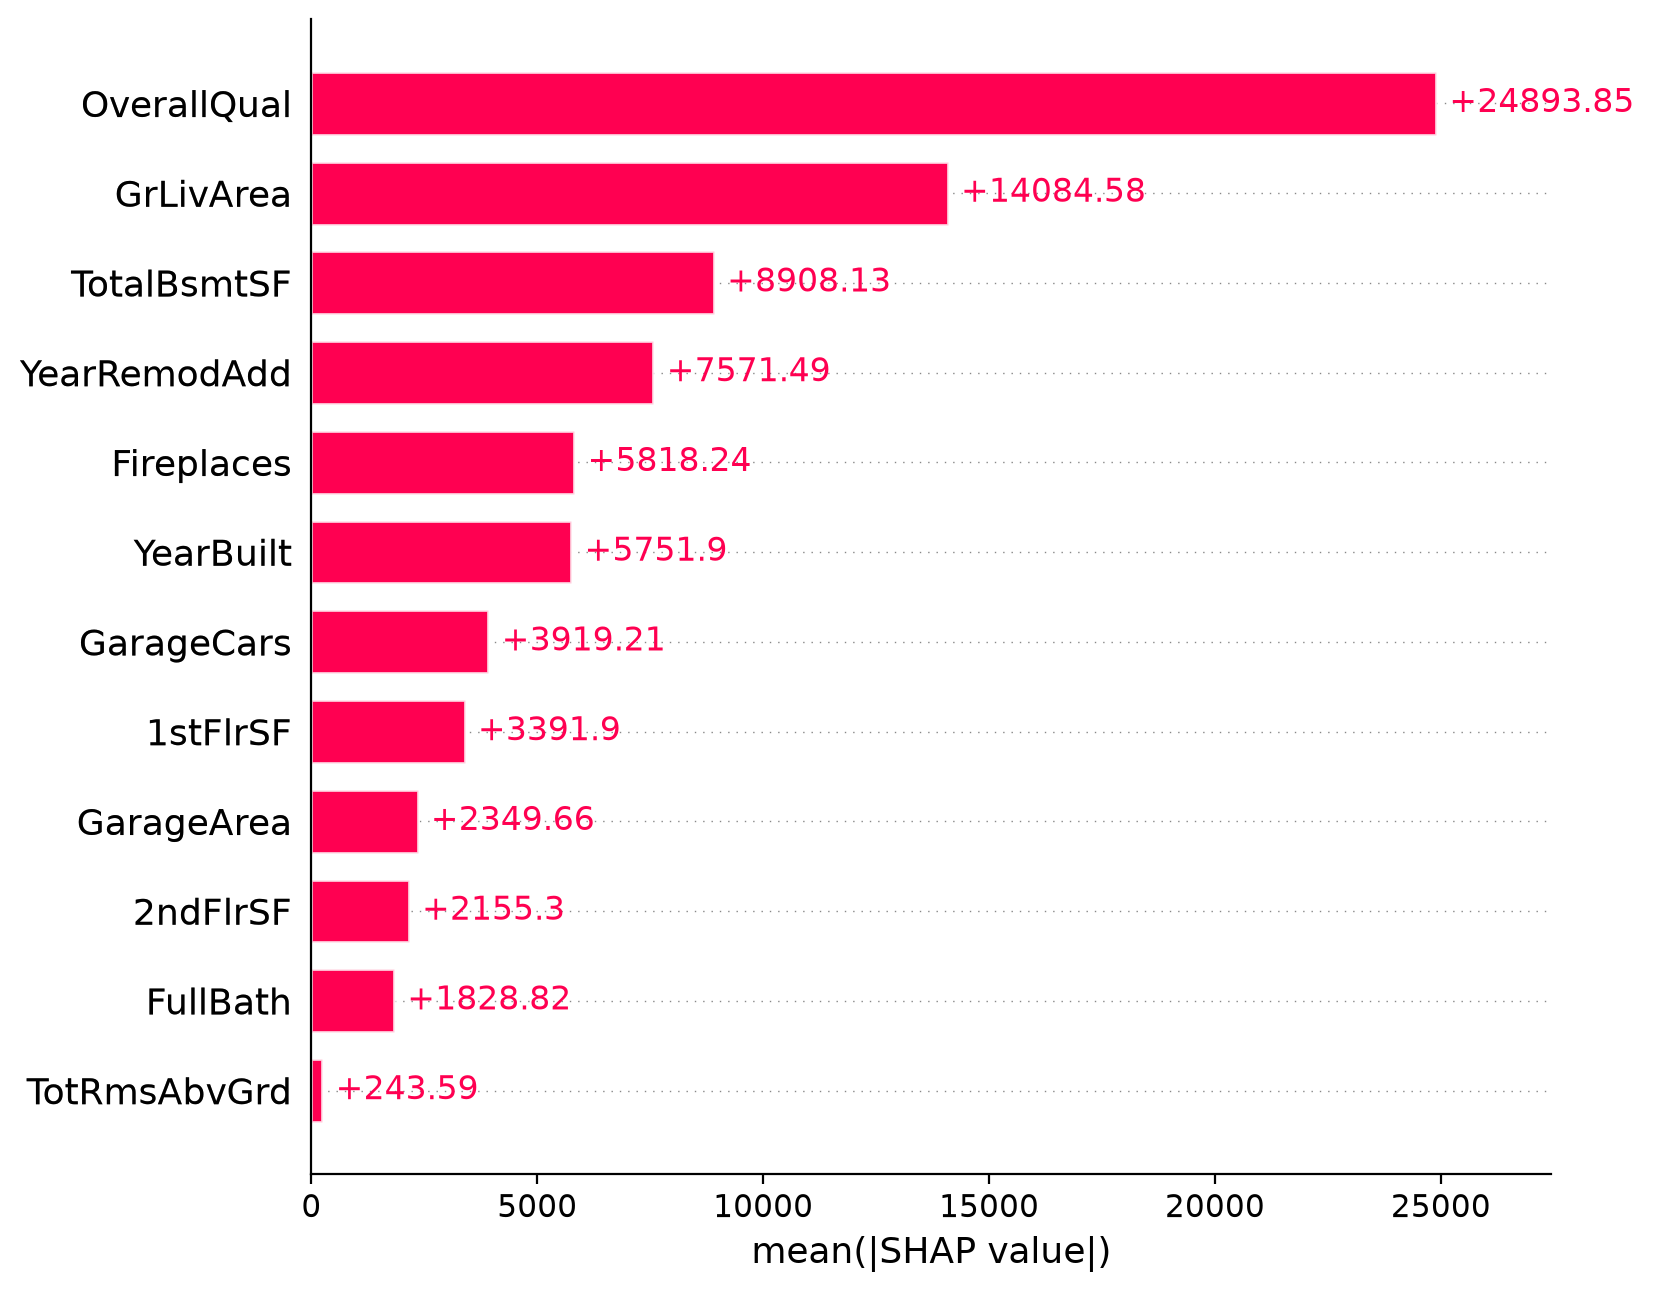

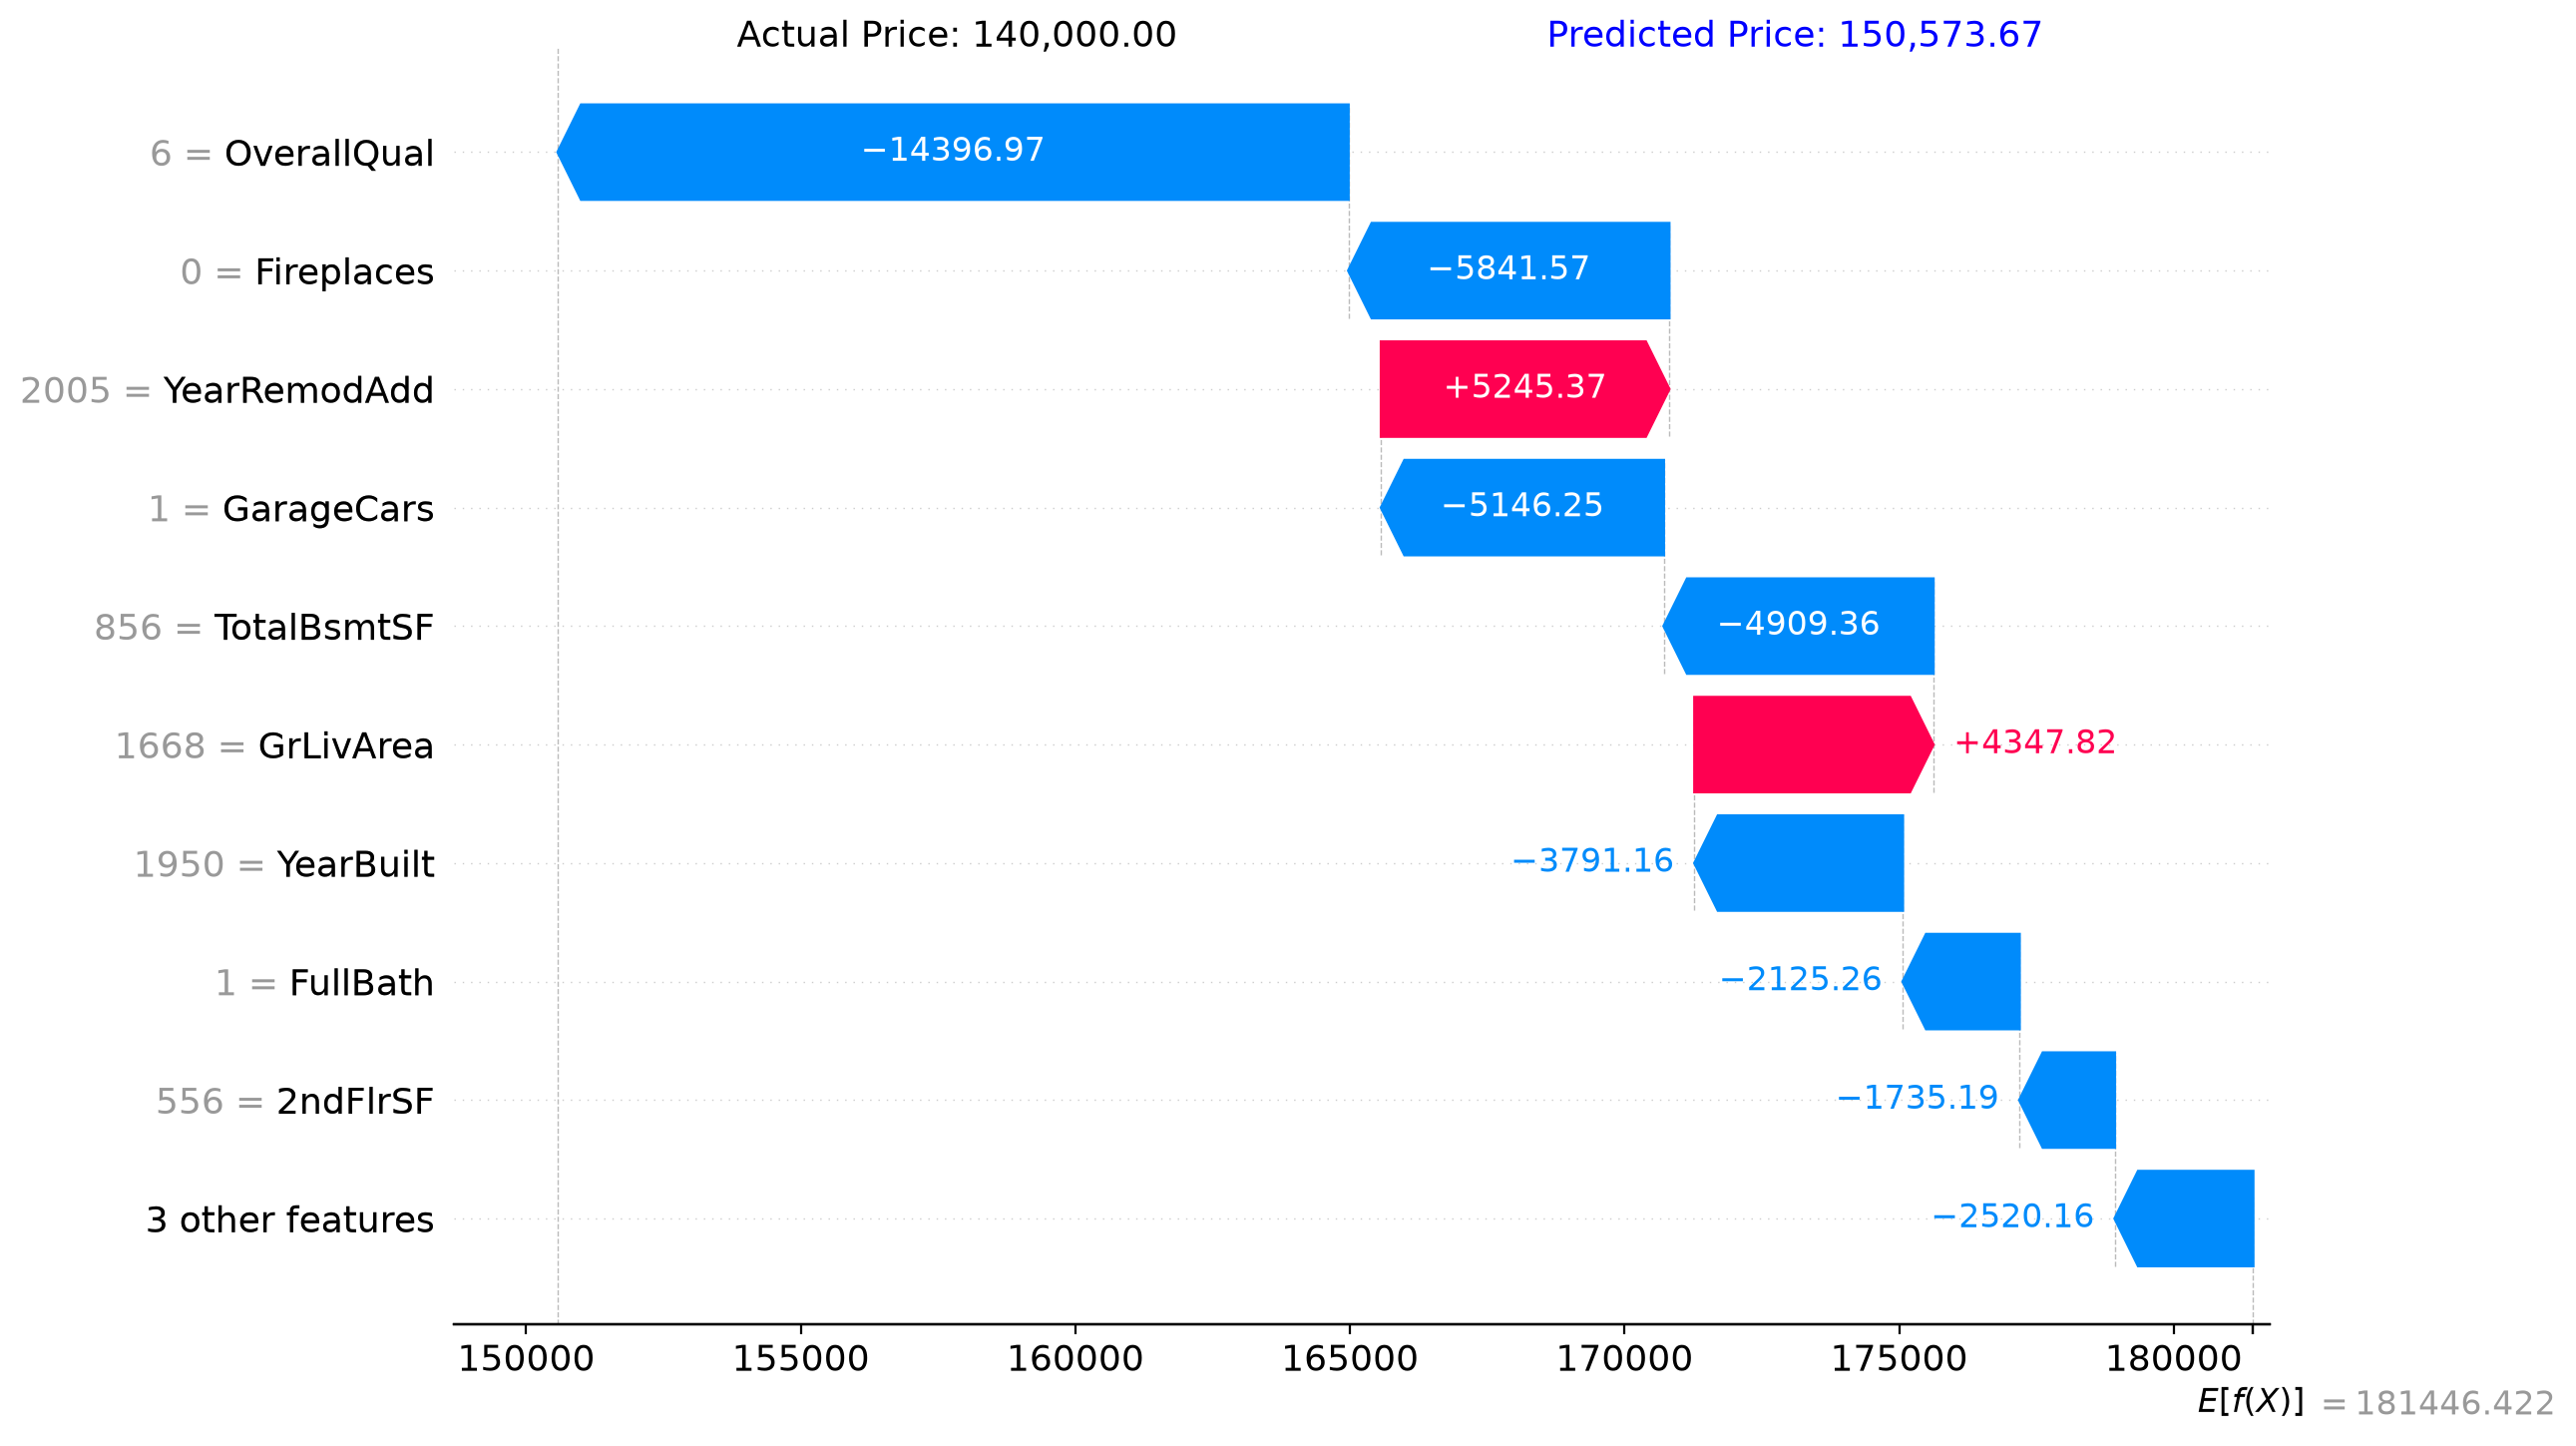

,Feature,Feature Value,SHAP Value,Abs SHAP
0,OverallQual,6,-14396.971680,14396.971680
1,Fireplaces,0,-5841.570801,5841.570801
2,YearRemodAdd,2005,5245.371582,5245.371582
3,GarageCars,1,-5146.245117,5146.245117
4,TotalBsmtSF,856,-4909.360840,4909.360840


SHAP 기준값: 181446.421875
모든 SHAP 값의 합: -30872.74
SHAP으로 계산한 예측값: 150573.69
XGBoost 예측값: 150573.67
예측값 일치 여부: True


In [6]:
# TODO 2: 과제용 XGBoost의 Feature Importance, Train_sub 전역 SHAP, Validation 첫 주택의 지역 SHAP을 확인하세요.


# 1. XGBoost Feature Importance
xgb_importance = xgb_model.feature_importances_


# 2. SHAP 계산
explainer = shap.TreeExplainer(xgb_model)

# Train_sub 전체를 기준으로 SHAP 계산
shap_train = explainer(X_sub)


# 3. 평균 절댓값 SHAP
mean_abs_shap = np.abs(shap_train.values).mean(axis=0)


# 4. 중요도 비교표 생성
importance_comparison = pd.DataFrame({
    "Feature": X_sub.columns,
    "XGBoost Importance": xgb_importance,
    "Mean Abs SHAP": mean_abs_shap
})


# 5. 각각 순위 계산
importance_comparison["XGB Rank"] = (
    importance_comparison["XGBoost Importance"]
    .rank(ascending=False, method="first")
    .astype(int)
)

importance_comparison["SHAP Rank"] = (
    importance_comparison["Mean Abs SHAP"]
    .rank(ascending=False, method="first")
    .astype(int)
)


# 6. SHAP 중요도 기준 정렬
importance_comparison = (
    importance_comparison
    .sort_values("SHAP Rank")
    .reset_index(drop=True)
)

display(importance_comparison)


# 7. SHAP 전역 중요도 막대그래프
shap.plots.bar(shap_train, max_display=X_sub.shape[1])

plt.show()


# 8. Validation 첫 번째 주택의 실제 가격과 예측 가격
house = X_val.iloc[[0]]

actual_price = np.asarray(y_val).ravel()[0]
predicted_price = xgb_model.predict(house)[0]


# 9. Validation 첫 번째 주택의 SHAP 값 계산
shap_local = explainer(house)


# 10. Waterfall Plot
# Validation 첫 번째 주택
house = X_val.iloc[[0]]

# 실제 가격
actual_price = np.asarray(y_val).ravel()[0]

# 예측 가격
predicted_price = xgb_model.predict(house)[0]

# SHAP 계산
shap_local = explainer(house)

# Waterfall Plot
shap.plots.waterfall(
    shap_local[0],
    max_display=10,
    show=False
)

# 그래프 크기
fig = plt.gcf()
fig.set_size_inches(14, 8)

# 기존 상단 예측값 표시 숨기기
ax_top = fig.axes[-1]
ax_top.set_xticks([])

# 실제 가격과 예측 가격을 별도로 표시
fig.text(
    0.48, 0.95,
    f"Actual Price: {actual_price:,.2f}",
    fontsize=13,
    ha="center",
    color="black"
)

fig.text(
    0.78, 0.95,
    f"Predicted Price: {predicted_price:,.2f}",
    fontsize=13,
    ha="center",
    color="blue"
)

# 여백 조정
fig.subplots_adjust(
    left=0.30,
    right=0.95,
    top=0.95,
    bottom=0.15
)

plt.show()


# 11. 지역 SHAP 상위 5개 특성 정리
local_top5 = pd.DataFrame({
    "Feature": X_val.columns,
    "Feature Value": house.iloc[0].values,
    "SHAP Value": shap_local.values[0]
})


# 12. SHAP 절댓값 계산
local_top5["Abs SHAP"] = local_top5["SHAP Value"].abs()


# 13. 절댓값 기준 상위 5개 특성 선택
local_top5 = (
    local_top5
    .sort_values("Abs SHAP", ascending=False)
    .head(5)
    .reset_index(drop=True)
)

display(local_top5)


# 14. SHAP 기준값 + 모든 SHAP 값의 합 확인
base_value = float(shap_local.base_values[0])

shap_sum = shap_local.values[0].sum()

shap_prediction = base_value + shap_sum


# 15. 예측값 비교
print("SHAP 기준값:", base_value)
print("모든 SHAP 값의 합:", shap_sum)
print("SHAP으로 계산한 예측값:", shap_prediction)
print("XGBoost 예측값:", predicted_price)


# 16. 예측값 일치 여부 확인
print(
    "예측값 일치 여부:",
    np.isclose(
        shap_prediction,
        predicted_price,
        rtol=1e-4,
        atol=1e-3
    )
)

In [7]:
# TODO 3: Train_sub SHAP 상위 6개 특성으로 재학습하고 동일 Validation에서 전후 성능을 비교하세요.

# 1. SHAP 중요도 상위 6개 특성 선택
selected_features = (
    importance_comparison
    .sort_values("Mean Abs SHAP", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

print("선택된 특성:", selected_features)


# 2. 선택한 특성만 사용
X_sub_selected = X_sub[selected_features]
X_val_selected = X_val[selected_features]


# 3. XGBoost 모델 생성 (기존 모델과 동일한 설정)
xgb_selected = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


# 4. 학습 및 학습 시간 측정
start = time.perf_counter()

xgb_selected.fit(X_sub_selected, y_sub)

selected_fit_time = time.perf_counter() - start


# 5. 기존 모델 예측
original_train_pred = xgb_model.predict(X_sub)
original_val_pred = xgb_model.predict(X_val)


# 6. 선택 특성 모델 예측
selected_train_pred = xgb_selected.predict(X_sub_selected)
selected_val_pred = xgb_selected.predict(X_val_selected)


# 7. 성능 비교표 생성
feature_comparison = pd.DataFrame([
    {
        "Model": "All Features",
        "Features": X_sub.shape[1],
        "Fit Time": model_comparison.loc[model_comparison['model']=="XGB", "progress_time"].iloc[0],
        "Train RMSE": np.sqrt(mean_squared_error(y_sub, original_train_pred)),
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, original_val_pred)),
        "Validation R2": r2_score(y_val, original_val_pred)
    },
    {
        "Model": "Selected Features",
        "Features": len(selected_features),
        "Fit Time": selected_fit_time,
        "Train RMSE": np.sqrt(mean_squared_error(y_sub, selected_train_pred)),
        "Validation RMSE": np.sqrt(mean_squared_error(y_val, selected_val_pred)),
        "Validation R2": r2_score(y_val, selected_val_pred)
    }
])

feature_comparison = feature_comparison.set_index("Model")

display(feature_comparison.round(4))


# 8. RMSE 개선량 및 개선율 계산
original_rmse = feature_comparison.loc["All Features", "Validation RMSE"]
selected_rmse = feature_comparison.loc["Selected Features", "Validation RMSE"]

rmse_improvement = original_rmse - selected_rmse
improvement_rate = (rmse_improvement / original_rmse) * 100


# 9. 결과 출력
print(f"기존 Validation RMSE: {original_rmse:.4f}")
print(f"선택 후 Validation RMSE: {selected_rmse:.4f}")
print(f"RMSE 개선량: {rmse_improvement:.4f}")
print(f"RMSE 개선율: {improvement_rate:.2f}%")


# 10. 개선 여부 확인
if rmse_improvement > 0:
    print("특성 선택 후 성능이 개선되었습니다.")
elif rmse_improvement < 0:
    print("특성 선택 후 성능이 악화되었습니다.")
else:
    print("특성 선택 전후 성능이 동일합니다.")

선택된 특성: ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'YearRemodAdd', 'Fireplaces', 'YearBuilt']


,Features,Fit Time,Train RMSE,Validation RMSE,Validation R2
Model,,,,,
All Features,12,0.1362,19933.9694,20747.7760,0.9334
Selected Features,6,0.1254,20282.4803,30029.8571,0.8605


기존 Validation RMSE: 20747.7760
선택 후 Validation RMSE: 30029.8571
RMSE 개선량: -9282.0812
RMSE 개선율: -44.74%
특성 선택 후 성능이 악화되었습니다.


## Q5~Q9 답변

-  Q5. 전역 SHAP에서 가장 중요한 특성이 특정 주택에서도 반드시 가장 큰 영향을 주나요?
    
    - 아니요
    
    - 전역 SHAP는 전체 데이터에서 각 특성이 예측에 미치는 영향의 절댓값읅 평균내어 계산한 중요도이다.
    - 특정 주택의 영향도는 지역 SHAP로, 특정 주택 하나에 대해 영향을 주는 특성별 기여도를 의미한다.
    - 따라서 두 중요도의 의미가 상이하기 때문에, 전체 데이터에서 중요도가 높은 특성이 특정 주택에서는 영향이 작을 수 있으며, 반대로 전역 중요도가 낮은 특성이 특정 주택에서는 큰 영향을 미칠 수 있다.

-  Q6. SHAP 값이 양수/음수라는 것은 각각 무엇을 의미하나요?
    
    - 양수는 기준 예측보다 예측값을 증가하게 하는 기여를 보이는 것이고,

    - 음수는 기준 예측보다 예측값을 감소하게 하는 기여를 보이는 것을 의미한다.


-  Q7. 두 모델 중 무엇을 우선 후보로 선택했나요? 성능·학습 시간·과적합 징후와 주택 가격 예측 업무를 연결하여 설명하세요.
    - XGB를 우선 후보로 선택하였다. 
    - validation의 R²의 성능이 0.88로 RF모델보다 높게 나타났으며,
    - 학습시간 또한 0.14초로 나타나 RF모델보다 빨랐다.
    - 과적합 여부는 train과 validation의 rmse 차이로 분석하였으며 XGB 모델이 -8320.21로 나타나 RF모델보다 작게 나타났다.
    - 따라서 XGB 모델을 우선 후보로 판단하였다.

-  Q8. Feature Importance와 평균 절댓값 SHAP의 계산 원리와 한계는 무엇이며, 실제 상위 특성 순위는 어떻게 다른가요?
    
    - Feature Importance의 원리는 피처가 트리 분할에 사용될 때 발생한 손실을 바탕으로 중요도를 계산한다.

    - 평균 절댓값 SHAP는 전역 중요도로, 각 피처가 예측값에 기여한 정도의 절댓값을 전체 데이터에서 평균하여 계산한다.

    - 따라서 Feature Importance는 특정 데이터에서 모델의 분할 과정에서 중요도를 평가하고, SHAP은 전체 데이터에서 예측값에 대한 기여도를 평가한다.


-  Q9. 상위 6개 특성은 무엇이며, 선택 전후 RMSE 차이와 개선율은 얼마인가요? 이 시도를 채택할지와 판단의 한계를 설명하세요.

    - 상위 6개의 특성은 [`OverallQual`, `GrLivArea`, `TotalBsmtSF`, `YearRemodAdd`, `Fireplaces`, `YearBuilt`]로 나타났다.
    - 기존 Validation의 RMSE는 20747.78이며, 선택 후 Validation RMSE는 30029.86로 나타나,
    - RMSE 개선량은 -9282.0812로 Validation의 RMSE 오차가 더 크게 나타났으며, RMSE 개선율이 -44.74%로 기존에 비해 개선하지 못하였다.
    - 따라서 6개의 특성을 사용하는 것이 아닌 전체 특성 모두를 사용하는 것을 고려해볼 수 있다.
    - 하지만 Validation의 결과만으로 성능 차이를 일반화하기 어렵다.

---

# 실습 마무리

아래 질문에 짧게 답해보세요.

1. 배깅과 부스팅의 학습 방식 차이는 무엇인가요?
    - 배깅 : 병렬, 독립 학습 후에 평균
    - 부스팅 : 순차학습으로 이전 오차를 보완

2. 배깅과 부스팅은 각각 편향과 분산 중 무엇을 줄이는 데 초점을 두나요?
    - 배깅 : 주로 분산 감소
    - 부스팅 : 주로 편향 감소

3. 튜닝 여력이 부족한 상황에서는 어떤 모델군을 먼저 고려할 수 있나요?
    - Random Forest를 베이스라인 후보로 고려할 수 있다.

4. Feature Importance의 가장 큰 한계는 무엇인가요?
    - 음/양의 방향성, 개별 예측 근거를 알기가 어려움

5. SHAP의 전역 해석과 지역 해석은 무엇이 다른가요?
    - 전역 해석 : 모델 전체에서 중요한 특성 파악
    - 지역 해석 : 특정 샘플의 예측 근거 설명

6. SHAP 값의 양수와 음수는 무엇을 의미하나요?
    - 양수 : 예측값 상승 방향
    - 음수 : 예측값 하락 방향